In [18]:
# Instalar bibliotecas caso não tenha
!pip install pandas numpy matplotlib seaborn openpyxl

# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Mu e Rox\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


importando as bibliotecas necessarias 

In [19]:
caminho = r'C:\Users\Mu e Rox\analise-salarios-publicos\data\raw\TB_RH.csv'
df = pd.read_csv(caminho, sep=';', encoding='utf-8')

# Verificando tamanho do arquivo
tamanho_bytes = os.path.getsize(caminho)
tamanho_mb = tamanho_bytes / (1024*1024)
print(f"Tamanho: {tamanho_bytes} bytes")
print(f"Tamanho: {tamanho_mb:.2f} MB")

# Visualizar primeiras linhas
df.head()

Tamanho: 187295997 bytes
Tamanho: 178.62 MB


,cod_vinculo,nome,sigla,instituicao,lotacao,municipio,cargo,dt_inicio,dt_fim,regime,quadro_funcional,quadro_funcional_desc,tipo_cargo,situacao,ult_remu_bruta,genero,ano_nasc,atualizado
0,707096,ALLAN DOUGLAS ROMAO,UEM,UNIVERSIDADE ESTADUAL DE MARINGA,DIVISAO DE SERVICOS GERAIS,MARINGA,AG. UNIVERSITARIO OPERACIONAL,2019-11-05,2021-11-01,CRES,CRES,TEMPORÁRIOS,****,DESLIGADO,0.00,M,1990.0,2021-12-01
1,770903,ALLAN DOUGLAS ROMAO,SESP,Secretaria da Segurança Pública e Administraçã...,****,CURITIBA,PROFISSIONAL DE NÍVEL MÉDIO,2021-10-22,2022-07-20,TEMPORÁRIO,CRES,TEMPORÁRIOS,****,DESLIGADO,0.00,M,1990.0,2022-08-01
2,45064,ALLAN DOUGLAS SALDANHA DE LIMA,SESP,Secretaria da Segurança Pública e Administraçã...,****,CAMPINA GRANDE DO SUL,SOLDADO 1ª CLASSE,2016-02-22,NaN,ESTATUTÁRIO,BM,QUADRO DO BOMBEIRO MILITAR,EFETIVO,ATIVO,7828.57,M,1988.0,2026-03-01
3,838206,ALLAN EDUARDO SCHAFER,SEED,SECRETARIA DA EDUCAÇÃO,ESC EST PE EDUARDO MICHELIS,SERRANOPOLIS DO IGUACU,DOCENTE POR PRAZO DETERMINADO,2023-06-25,2024-12-31,TEMPORÁRIO,CRES,TEMPORÁRIOS,****,DESLIGADO,0.00,M,2002.0,2025-02-01
4,911735,ALLAN EDUARDO SCHAFER,SEED,SECRETARIA DA EDUCAÇÃO,MISSAL,MISSAL,DOCENTE POR PRAZO DETERMINADO,2025-04-15,NaN,TEMPORÁRIO,CRES,TEMPORÁRIOS,****,ATIVO,332.92,M,2002.0,2026-03-01


In [20]:
# Colunas
df.columns

# Estrutura e tipos
df.info()

# Valores nulos por coluna
df.isnull().sum()

# Estatísticas descritivas básicas
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 890009 entries, 0 to 890008
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   cod_vinculo            890009 non-null  int64  
 1   nome                   890009 non-null  str    
 2   sigla                  890009 non-null  str    
 3   instituicao            890009 non-null  str    
 4   lotacao                886292 non-null  str    
 5   municipio              890009 non-null  str    
 6   cargo                  889990 non-null  str    
 7   dt_inicio              890009 non-null  str    
 8   dt_fim                 587306 non-null  str    
 9   regime                 890009 non-null  str    
 10  quadro_funcional       890009 non-null  str    
 11  quadro_funcional_desc  890009 non-null  str    
 12  tipo_cargo             890009 non-null  str    
 13  situacao               890009 non-null  str    
 14  ult_remu_bruta         890007 non-null  float64

,cod_vinculo,ult_remu_bruta,ano_nasc
count,890009.000000,890007.000000,890008.000000
mean,464367.215418,3058.415957,1972.244596
std,273807.994865,6172.885949,16.315169
min,1.000000,0.000000,1894.000000
25%,224694.000000,0.000000,1962.000000
50%,454278.000000,0.000000,1974.000000
75%,707616.000000,4916.660000,1985.000000
max,949002.000000,310075.090000,2025.000000


In [36]:
# Remover linhas totalmente vazias
df.dropna(how='all', inplace=True)

# Converter datas
df['dt_inicio'] = pd.to_datetime(df['dt_inicio'])
df['dt_fim'] = pd.to_datetime(df['dt_fim'])
df['atualizado'] = pd.to_datetime(df['atualizado'])

# Remover registros com remuneração zero
df = df[df['ult_remu_bruta'] > 0]

# Remover linhas com valores nulos na coluna de interesse
df = df.dropna(subset=['ult_remu_bruta'])

# 🔹 Filtrar apenas funcionários ativos
df = df[df['situacao'] == 'ATIVO']

In [37]:
# Idade dos servidores
df['idade'] = 2026 - df['ano_nasc']

# Tempo de serviço (anos)
df['tempo_servico'] = (pd.Timestamp('today') - df['dt_inicio']).dt.days / 365

In [38]:
# Remuneração média e mediana por cargo
df.groupby('cargo')['ult_remu_bruta'].agg(['mean', 'median', 'count']).sort_values('median', ascending=False)

# Total de remuneração por instituição
df.groupby('instituicao')['ult_remu_bruta'].sum().sort_values(ascending=False)

# Frequência de siglas
df['sigla'].value_counts()

sigla
SEED              92847
SESP              28181
SESA               6782
UEL                4466
UEM                3947
                  ...  
SEES                 44
INVEST               35
LOTEPAR              31
CEDEC                25
PARANAPROJETOS       11
Name: count, Length: 70, dtype: int64

In [39]:
# Mostra as primeiras 10 linhas
df.head(10)

,cod_vinculo,nome,sigla,instituicao,lotacao,municipio,cargo,dt_inicio,dt_fim,regime,quadro_funcional,quadro_funcional_desc,tipo_cargo,situacao,ult_remu_bruta,genero,ano_nasc,atualizado,idade,tempo_servico
2,45064,ALLAN DOUGLAS SALDANHA DE LIMA,SESP,Secretaria da Segurança Pública e Administraçã...,****,CAMPINA GRANDE DO SUL,SOLDADO 1ª CLASSE,2016-02-22,NaT,ESTATUTÁRIO,BM,QUADRO DO BOMBEIRO MILITAR,EFETIVO,ATIVO,7828.57,M,1988.0,2026-03-01,38.0,10.106849
4,911735,ALLAN EDUARDO SCHAFER,SEED,SECRETARIA DA EDUCAÇÃO,MISSAL,MISSAL,DOCENTE POR PRAZO DETERMINADO,2025-04-15,NaT,TEMPORÁRIO,CRES,TEMPORÁRIOS,****,ATIVO,332.92,M,2002.0,2026-03-01,24.0,0.956164
10,435894,ALLAN FELIPE GARCIA,SESP,Secretaria da Segurança Pública e Administraçã...,****,****,****,2013-11-11,NaT,ESTATUTÁRIO,PM,POLÍCIA MILITAR,EFETIVO,ATIVO,7828.57,M,1991.0,2026-03-01,35.0,12.389041
14,401423,ALLAN FELIX SANCHES,SESP,Secretaria da Segurança Pública e Administraçã...,****,****,****,2012-05-21,NaT,ESTATUTÁRIO,PM,POLÍCIA MILITAR,EFETIVO,ATIVO,9363.77,M,1987.0,2026-03-01,39.0,13.865753
15,165219,ALLAN FELLIPE GOMES MURAROTO,SESP,Secretaria da Segurança Pública e Administraçã...,****,****,****,2013-11-11,NaT,ESTATUTÁRIO,PM,POLÍCIA MILITAR,EFETIVO,ATIVO,10159.61,M,1991.0,2026-03-01,35.0,12.389041
23,34281,ALLAN FERNANDO BANASEWICZ,SESP,Secretaria da Segurança Pública e Administraçã...,****,****,****,2014-04-10,NaT,ESTATUTÁRIO,QPPC,POLÍCIA CIVIL,EFETIVO,ATIVO,10714.96,M,1986.0,2026-03-01,40.0,11.978082
27,920834,ALLAN FERREIRA DA SILVA,UEL,UNIVERSIDADE ESTADUAL DE LONDRINA,Secretaria Administrativa,LONDRINA,PROFISSIONAL DE NÍVEL MÉDIO,2025-08-04,NaT,TEMPORÁRIO,CRES,TEMPORÁRIOS,****,ATIVO,4261.05,M,1986.0,2026-03-01,40.0,0.652055
29,868598,ALLAN GUSMÃO TIVANELLO,SEED,SECRETARIA DA EDUCAÇÃO,NRE LONDRINA - LOCAL,LONDRINA,PROFESSOR,2024-08-29,NaT,ESTATUTÁRIO,QPM,MAGISTÉRIO,EFETIVO,ATIVO,3588.55,M,1994.0,2026-03-01,32.0,1.583562
34,898039,ALLAN FERREIRA FRANCO,SEED,SECRETARIA DA EDUCAÇÃO,E E OLINDAMIR M CLAURDINO-EF,FAZENDA RIO GRANDE,DOCENTE POR PRAZO DETERMINADO,2025-02-03,NaT,TEMPORÁRIO,CRES,TEMPORÁRIOS,****,ATIVO,6523.31,M,1993.0,2026-03-01,33.0,1.150685
39,269832,ALLAN FRANCO DE CAMARGO,SESP,Secretaria da Segurança Pública e Administraçã...,****,****,****,2013-11-11,NaT,ESTATUTÁRIO,PM,POLÍCIA MILITAR,EFETIVO,ATIVO,7828.57,M,1983.0,2026-03-01,43.0,12.389041


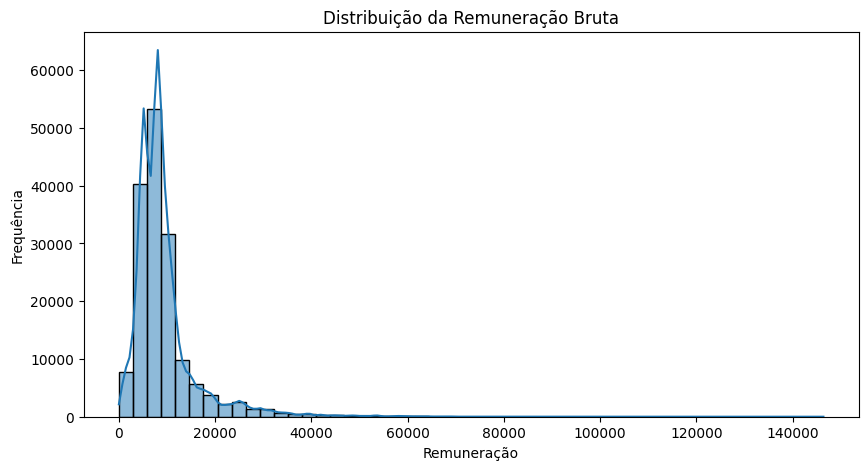

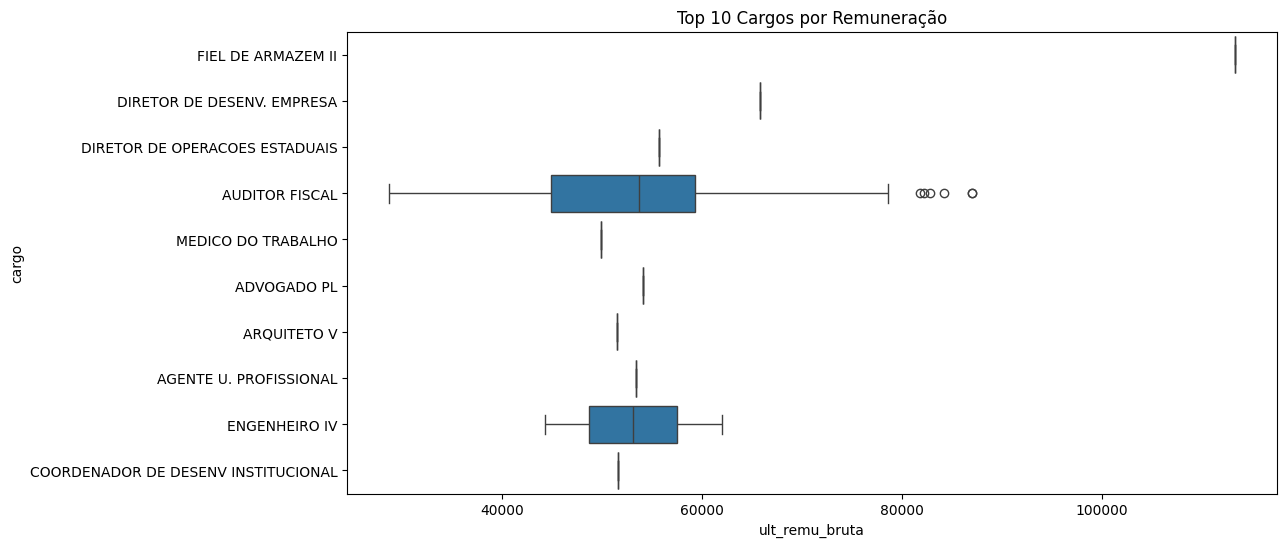

In [40]:
# Histograma de remuneração
plt.figure(figsize=(10,5))
sns.histplot(df['ult_remu_bruta'], bins=50, kde=True)
plt.title('Distribuição da Remuneração Bruta')
plt.xlabel('Remuneração')
plt.ylabel('Frequência')
plt.show()

# Boxplot por cargo
plt.figure(figsize=(12,6))
top_cargos = df.groupby('cargo')['ult_remu_bruta'].median().sort_values(ascending=False).head(10).index
sns.boxplot(x='ult_remu_bruta', y='cargo', data=df[df['cargo'].isin(top_cargos)])
plt.title('Top 10 Cargos por Remuneração')
plt.show()

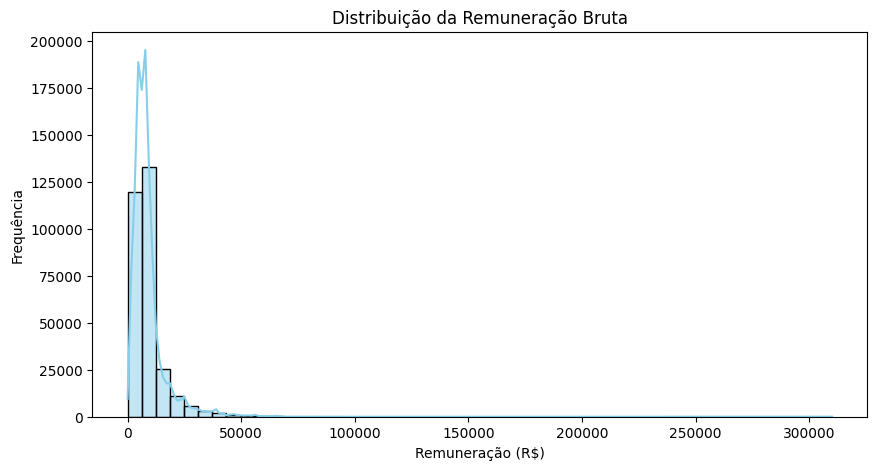

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(df['ult_remu_bruta'], bins=50, kde=True, color='skyblue')
plt.title('Distribuição da Remuneração Bruta')
plt.xlabel('Remuneração (R$)')
plt.ylabel('Frequência')
plt.show()

C:\Users\Mu e Rox\AppData\Local\Temp\ipykernel_17460\1890748149.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ult_remu_bruta', y='cargo', data=df[df['cargo'].isin(top10_cargos)], palette='Set2')


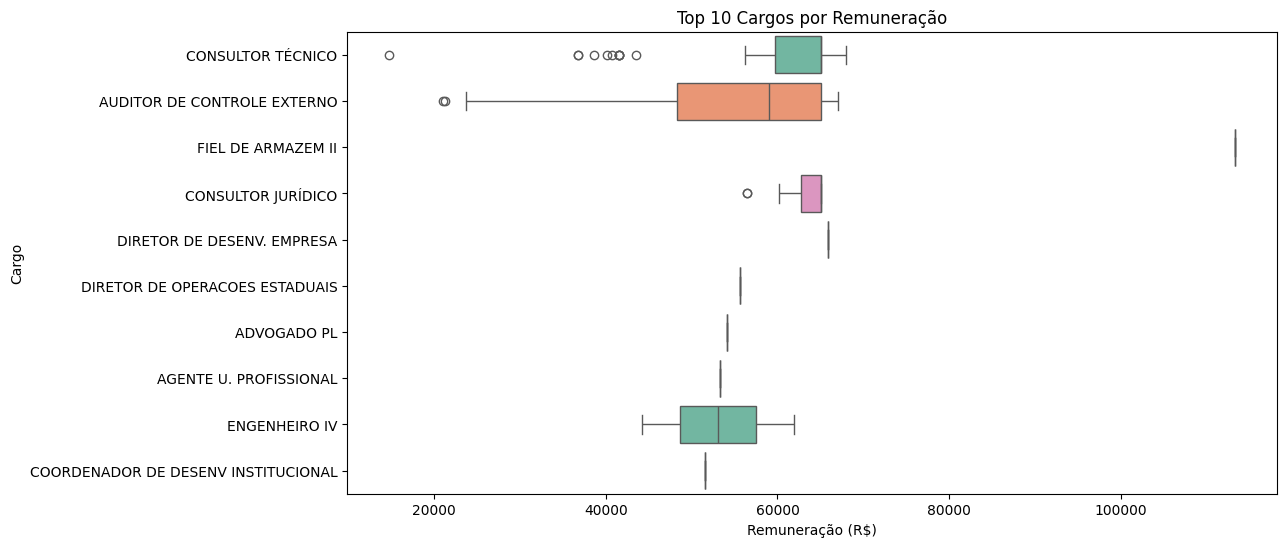

In [28]:
plt.figure(figsize=(12,6))
top10_cargos = df.groupby('cargo')['ult_remu_bruta'].median().sort_values(ascending=False).head(10).index
sns.boxplot(x='ult_remu_bruta', y='cargo', data=df[df['cargo'].isin(top10_cargos)], palette='Set2')
plt.title('Top 10 Cargos por Remuneração')
plt.xlabel('Remuneração (R$)')
plt.ylabel('Cargo')
plt.show()

C:\Users\Mu e Rox\AppData\Local\Temp\ipykernel_17460\1249904036.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_instituicoes.values, y=top_instituicoes.index, palette='magma')


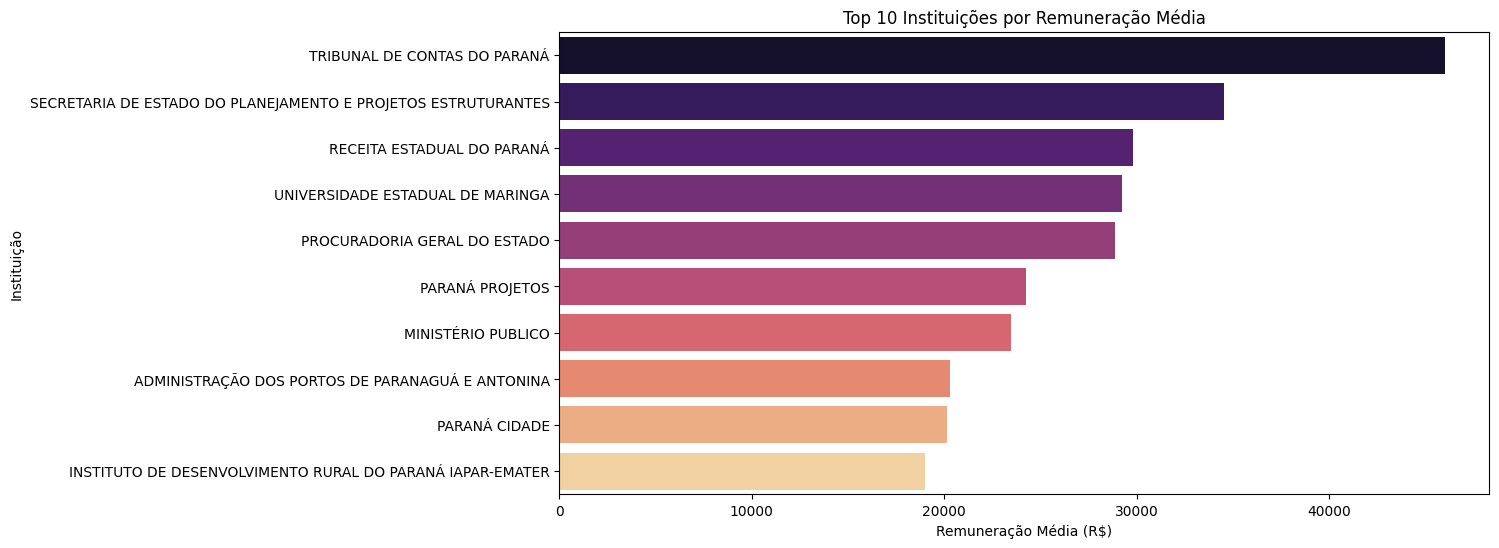

In [29]:
plt.figure(figsize=(12,6))
top_instituicoes = df.groupby('instituicao')['ult_remu_bruta'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_instituicoes.values, y=top_instituicoes.index, palette='magma')
plt.title('Top 10 Instituições por Remuneração Média')
plt.xlabel('Remuneração Média (R$)')
plt.ylabel('Instituição')
plt.show()

C:\Users\Mu e Rox\AppData\Local\Temp\ipykernel_17460\881619613.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genero', y='ult_remu_bruta', data=df, palette='pastel')


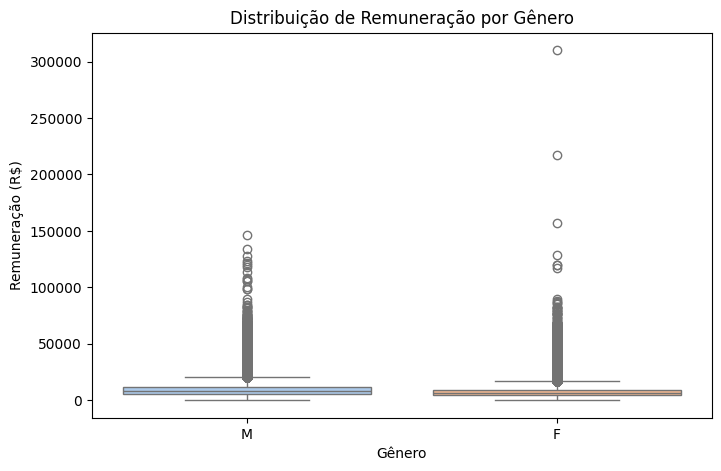

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x='genero', y='ult_remu_bruta', data=df, palette='pastel')
plt.title('Distribuição de Remuneração por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Remuneração (R$)')
plt.show()

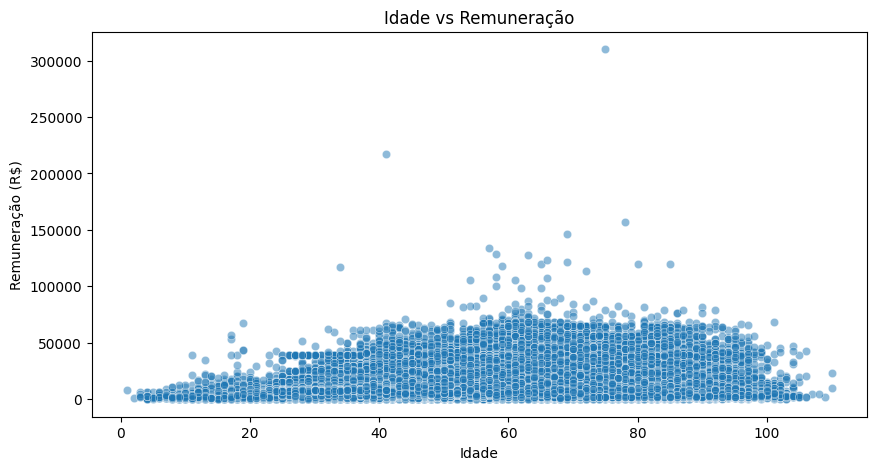

In [31]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='idade', y='ult_remu_bruta', data=df, alpha=0.5)
plt.title('Idade vs Remuneração')
plt.xlabel('Idade')
plt.ylabel('Remuneração (R$)')
plt.show()

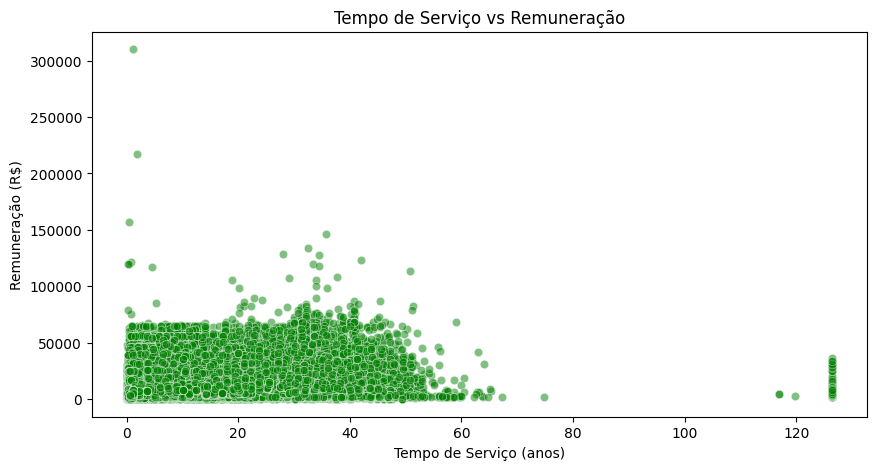

In [32]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='tempo_servico', y='ult_remu_bruta', data=df, alpha=0.5, color='green')
plt.title('Tempo de Serviço vs Remuneração')
plt.xlabel('Tempo de Serviço (anos)')
plt.ylabel('Remuneração (R$)')
plt.show()

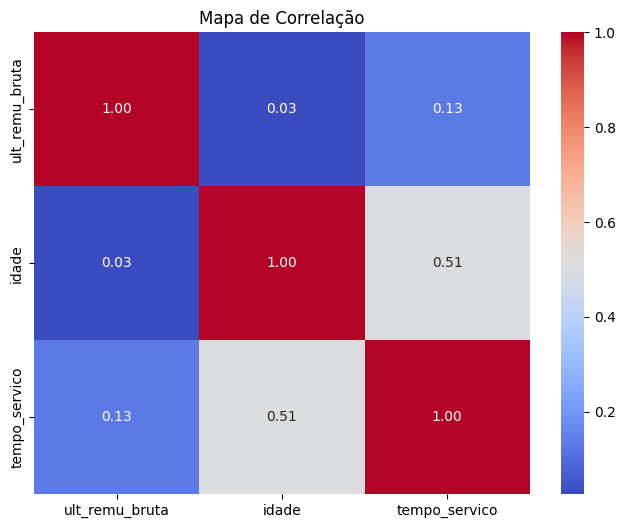

In [33]:
plt.figure(figsize=(8,6))
corr = df[['ult_remu_bruta', 'idade', 'tempo_servico']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlação')
plt.show()

C:\Users\Mu e Rox\AppData\Local\Temp\ipykernel_17460\4216689627.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_siglas.values, y=top10_siglas.index, palette='viridis')


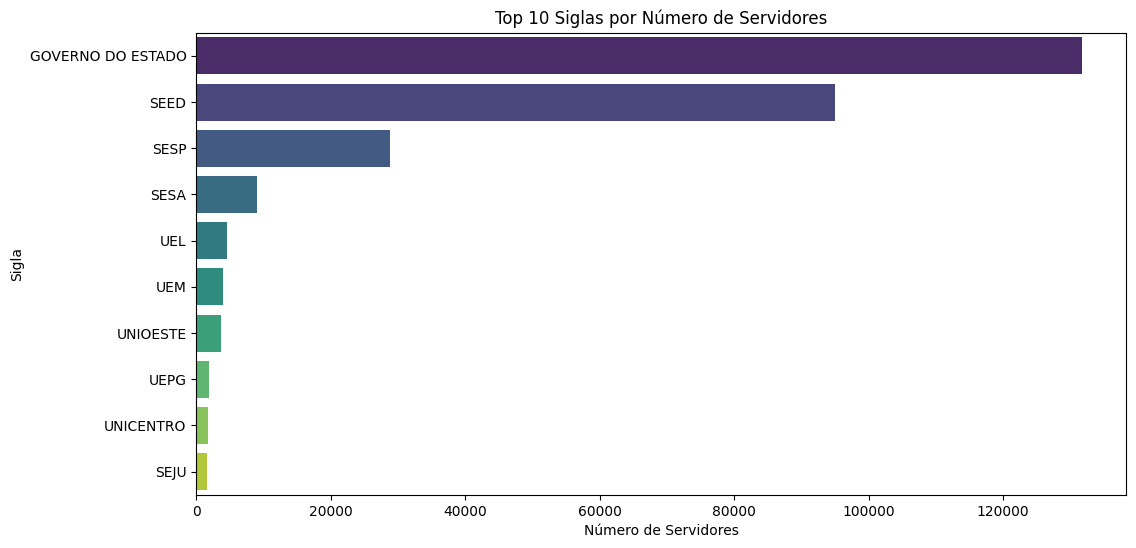

In [34]:
plt.figure(figsize=(12,6))
top10_siglas = df['sigla'].value_counts().head(10)
sns.barplot(x=top10_siglas.values, y=top10_siglas.index, palette='viridis')
plt.title('Top 10 Siglas por Número de Servidores')
plt.xlabel('Número de Servidores')
plt.ylabel('Sigla')
plt.show()

In [ ]:
# Salvar CSV processado (sem linhas vazias, sem remuneração zero)
df.to_csv(r'C:\Users\Mu e Rox\analise-salarios-publicos\data\processed\TB_RH_limpo.csv', index=False, encoding='utf-8')

cod_vinculo                   0
nome                          0
sigla                         0
instituicao                   0
lotacao                      12
municipio                     0
cargo                         0
dt_inicio                     0
dt_fim                   299864
regime                        0
quadro_funcional              0
quadro_funcional_desc         0
tipo_cargo                    0
situacao                      0
ult_remu_bruta                0
genero                        0
ano_nasc                      0
atualizado                    0
dtype: int64